# Shark Attacks — Data Cleaning Practice (Ironhack Week 2 Quest)

Practice project for the Ironhack Data Analytics bootcamp — Week 2, Quest 2
("Data Wrangling"). Not production code: the goal is to practice pandas data
cleaning techniques (missing values, duplicates, string/regex cleanup, date
parsing) on a genuinely messy real-world dataset, then run basic EDA to check
a hypothesis.

**Dataset:** [Global Shark Attack File (GSAF)](https://www.sharkattackfile.net/incidentlog.htm),
downloaded as `data/GSAF5.xls`.

**Hypothesis:** certain activities (swimming, surfing, diving, fishing...)
carry more shark-attack risk than others.

**Business case:** a company selling surf/diving trips wants to know which
*activities* and *locations* carry the highest shark-attack risk, to help
decide where to run trips and what to flag to customers.

> **Note on this notebook:** this is the **group** version, combining the
> shared cleaning pipeline (`cleaning.py`/`eda.py`) with a "Team Addendum"
> at the end that documents what each teammate explored and contributed.
> Each teammate also has her own **individual** notebook for her personal
> submission — those may go further on a specific angle, include extra
> points, alternative approaches, or conclusions she found particularly
> worth exploring on her own. This shared notebook is the common ground;
> the individual ones are where personal exploration and extra credit live.

## Day 1 — Load & first look

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from cleaning import clean_shark_data
from eda import (
    top_activities,
    fatality_rate_by_activity,
    attacks_by_activity_and_country,
    plot_top_activities,
    plot_fatality_rate_by_activity,
)

pd.set_option("display.max_columns", None)

raw = pd.read_excel("data/GSAF5.xls")
raw.shape

(7103, 23)

In [2]:
raw.head(3)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,Not stated,N,1530hrs,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,Bite to back of ankle,N,1145hrs,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,Bite wound to L thigh bite wounds both arms L ...,N,1115hrs,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Column types and missing values before cleaning
missing_pct = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct

Unnamed: 22       100.0
Unnamed: 21       100.0
Time               49.7
Species            44.1
Age                42.2
Activity            8.2
Sex                 8.1
Location            8.0
Fatal Y/N           7.9
State               6.9
href formula        4.4
pdf                 4.3
href                4.3
Case Number         4.3
Case Number.1       4.3
original order      4.3
Name                3.1
Country             0.7
Injury              0.5
Source              0.3
Type                0.3
Year                0.0
Date                0.0
dtype: float64

In [4]:
# A closer look at Fatal Y/N before touching anything
raw["Fatal Y/N"].value_counts()

Fatal Y/N
N          4956
Y          1494
UNKNOWN      71
 N            7
F             5
M             3
n             1
Nq            1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64

**Issues spotted:**
- `Unnamed: 21` / `Unnamed: 22` are 100% empty.
- `Age` is free text (`"20's"`, `"30+"`, `"?"`, multi-victim lists like `"21, 34,24 & 35"`).
- `Type`, `Sex`, `Fatal Y/N` have inconsistent casing, stray whitespace and
  outright data-entry errors (e.g. `Fatal Y/N` contains the value `2017`).
- `Date` has no year for older rows (`"23rd June"`) and mixes several date formats.
- Several text columns (e.g. `Activity`) silently duplicate categories only
  because of trailing whitespace (`"Swimming"` vs `"Swimming "`).

## Day 2 — Cleaning (everything but dates)

All cleaning techniques live in [`cleaning.py`](cleaning.py) as small,
single-purpose functions, chained together by `clean_shark_data()`. That
keeps the notebook focused on the *narrative* — what was wrong and why each
fix was applied — while the reusable logic stays in a plain `.py` module.

Techniques applied (more than the 5 required):
1. **Drop unused columns** — fully-empty columns and administrative link fields.
2. **Strip whitespace** on every text column (fixes silently duplicated categories).
3. **Standardize column names** to snake_case.
4. **Clean categorical columns** (`type`, `sex`, `fatal`) — map inconsistent
   spellings/casing/junk values to a small fixed set, using `"Unknown"` as an
   explicit fallback instead of silently keeping garbage.
5. **Clean country names** — uppercase + fix known typos (e.g. `GALAPOGOS ISLANDS`).
6. **Extract numeric age via regex** from the messy `age` text column.
7. **Parse dates** (see Day 3 below).
8. **Fill missing categoricals** (`activity`, `species`, ...) with `"Unknown"`
   instead of `NaN`, so they aren't silently dropped from `groupby`/`value_counts`.
9. **Remove duplicate rows** (checked after cleaning).

In [5]:
clean = clean_shark_data(raw)
print("raw shape:  ", raw.shape)
print("clean shape:", clean.shape)
clean.dtypes

raw shape:   (7103, 23)
clean shape: (7103, 20)


date                   object
year                  float64
type                   object
country                object
state                  object
location               object
activity               object
name                   object
sex                    object
age                   float64
injury                 object
fatal                  object
time                   object
species                object
source                 object
case_number            object
age_raw                object
date_raw               object
date_parsed    datetime64[ns]
month                  object
dtype: object

In [6]:
# Before vs after: Type, Sex, Fatal collapse to a small, consistent set of values
for col in ["type", "sex", "fatal"]:
    print(f"--- {col} ---")
    display(clean[col].value_counts())
    print()

--- type ---


type
Unprovoked             5252
Provoked                646
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
Unknown                  19
Boat                      7
Unconfirmed               1
Unverified                1
Under Investigation       1
Name: count, dtype: int64


--- sex ---


sex
M          5700
F           817
Unknown     586
Name: count, dtype: int64


--- fatal ---


fatal
N          4966
Y          1496
Unknown     641
Name: count, dtype: int64

### Data Quality Before & After

Each cleaning technique removed duplicates/noise and standardized values — here's what that looked like in practice.

In [7]:
# Examples of transformation per technique
before_after = pd.DataFrame({
    "Technique": [
        "Strip whitespace",
        "Strip whitespace",
        "Clean categorical (Type)",
        "Clean categorical (Sex)",
        "Clean categorical (Fatal)",
        "Clean country",
        "Extract age (regex)"
    ],
    "Raw value": [
        '"Swimming "',
        '"Spearfishing "',
        '"UNprovoked"',
        '"M "',
        '"Y x 2"',
        '"Galapogos Islands"',
        '"20\'s"'
    ],
    "Clean value": [
        '"Swimming"',
        '"Spearfishing"',
        '"Unprovoked"',
        '"M"',
        '"Unknown"',
        '"GALAPAGOS ISLANDS"',
        '20'
    ]
})
print("Examples of transformations applied:")
display(before_after)

Examples of transformations applied:


,Technique,Raw value,Clean value
0,Strip whitespace,"""Swimming ""","""Swimming"""
1,Strip whitespace,"""Spearfishing ""","""Spearfishing"""
2,Clean categorical (Type),"""UNprovoked""","""Unprovoked"""
3,Clean categorical (Sex),"""M ""","""M"""
4,Clean categorical (Fatal),"""Y x 2""","""Unknown"""
5,Clean country,"""Galapogos Islands""","""GALAPAGOS ISLANDS"""
6,Extract age (regex),"""20's""",20


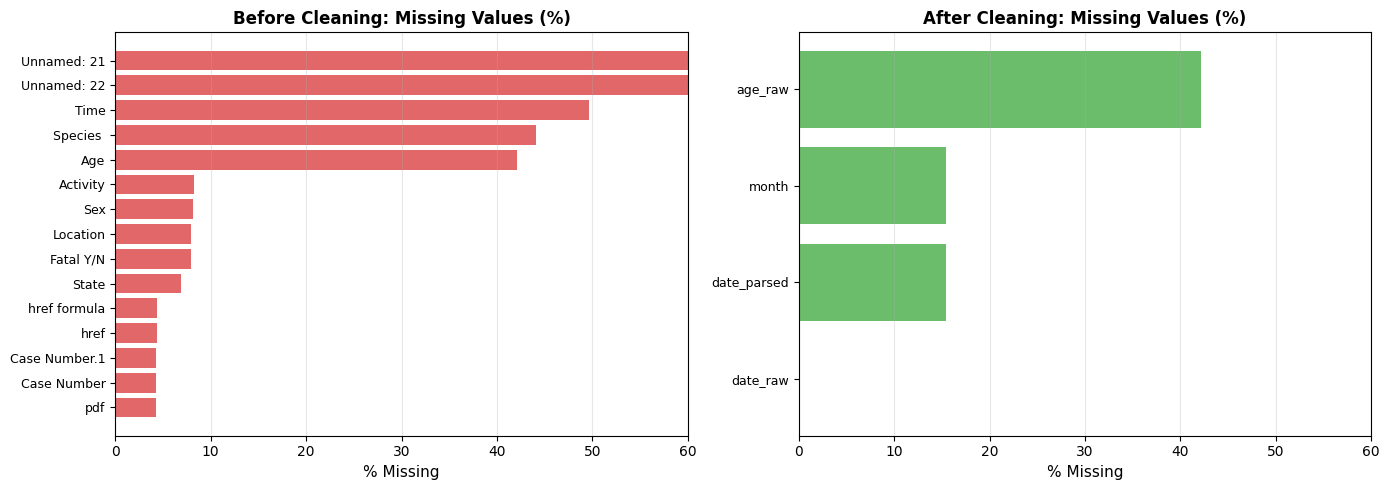


✓ Dataset shape: 7,103 rows × 23 columns (raw) → 7,103 rows × 20 columns (clean)
✓ No rows dropped — only columns removed and values standardized
✓ Categorical missing values filled with 'Unknown' to preserve row counts in groupby operations
✓ Numeric missing values (age, date) kept as NaN — never imputed or fabricated


In [8]:
# Visualize data completeness: before vs after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning: missing values %
raw_missing = (raw.isna().sum() / len(raw) * 100).sort_values(ascending=True)
# Focus on the main columns (exclude fully-empty ones for clarity)
raw_missing_main = raw_missing[raw_missing < 100].tail(15)

ax1.barh(range(len(raw_missing_main)), raw_missing_main.values, color="#d62728", alpha=0.7)
ax1.set_yticks(range(len(raw_missing_main)))
ax1.set_yticklabels(raw_missing_main.index, fontsize=9)
ax1.set_xlabel("% Missing", fontsize=11)
ax1.set_title("Before Cleaning: Missing Values (%)", fontsize=12, fontweight="bold")
ax1.set_xlim(0, 60)
ax1.grid(axis="x", alpha=0.3)

# After cleaning: missing values % (excluding dropped columns)
clean_cols = [c for c in clean.columns if c in raw.columns or c in ["age_raw", "date_raw", "date_parsed", "month"]]
clean_missing = (clean[clean_cols].isna().sum() / len(clean) * 100).sort_values(ascending=True)
# Show same columns where possible
clean_missing_main = clean_missing[clean_missing < 50]

ax2.barh(range(len(clean_missing_main)), clean_missing_main.values, color="#2ca02c", alpha=0.7)
ax2.set_yticks(range(len(clean_missing_main)))
ax2.set_yticklabels(clean_missing_main.index, fontsize=9)
ax2.set_xlabel("% Missing", fontsize=11)
ax2.set_title("After Cleaning: Missing Values (%)", fontsize=12, fontweight="bold")
ax2.set_xlim(0, 60)
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("data_quality_before_after.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n✓ Dataset shape: 7,103 rows × 23 columns (raw) → 7,103 rows × 20 columns (clean)")
print("✓ No rows dropped — only columns removed and values standardized")
print("✓ Categorical missing values filled with 'Unknown' to preserve row counts in groupby operations")
print("✓ Numeric missing values (age, date) kept as NaN — never imputed or fabricated")

## Day 3 — Dates, structuring & aggregation

`parse_attack_date` (in `cleaning.py`) strips ordinal suffixes (`"23rd"` →
`"23"`), merges the day+month text with the `year` column for older rows, and
falls back to `pandas.to_datetime` directly for rows that already look like a
parseable date. Genuinely unparseable entries (`"Before 1906"`, `"1900-1905"`
range strings) are kept as `NaT` rather than dropped or guessed at.

In [9]:
parsed_pct = clean["date_parsed"].notna().mean() * 100
print(f"Dates successfully parsed: {parsed_pct:.1f}% of rows")
clean["date_parsed"].dt.year.value_counts().sort_index().tail(15)

Dates successfully parsed: 84.6% of rows


date_parsed
2012.0    113
2013.0    116
2014.0    117
2015.0    142
2016.0    128
2017.0    130
2018.0    118
2019.0    109
2020.0     97
2021.0    108
2022.0     97
2023.0    101
2024.0     10
2025.0     41
2026.0     38
Name: count, dtype: int64

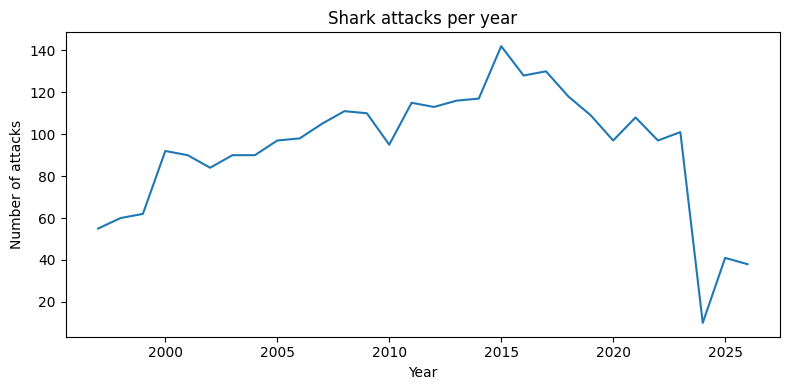

In [10]:
# Attacks per year (last 30 years with data) — simple aggregation
by_year = (
    clean.dropna(subset=["date_parsed"])
    .assign(attack_year=lambda d: d["date_parsed"].dt.year)
    .groupby("attack_year")
    .size()
)
by_year.tail(30).plot(kind="line", figsize=(8, 4), title="Shark attacks per year")
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.tight_layout()
plt.savefig("attacks_per_year.png", dpi=100)
plt.show()

In [11]:
# Pivot: activity x country, for the top activities/countries — structuring for EDA
top5_activities = top_activities(clean, n=5).index.tolist()
attacks_by_activity_and_country(clean, top5_activities, None, n=6)

activity,Fishing,Spearfishing,Surfing,Swimming,Wading
country,,,,,
AUSTRALIA,129,94,258,208,18
BAHAMAS,3,43,2,8,1
NEW ZEALAND,19,12,17,22,2
PAPUA NEW GUINEA,19,23,0,11,2
SOUTH AFRICA,48,51,100,95,9
USA,147,65,671,388,124


## Day 4 — EDA & hypothesis validation

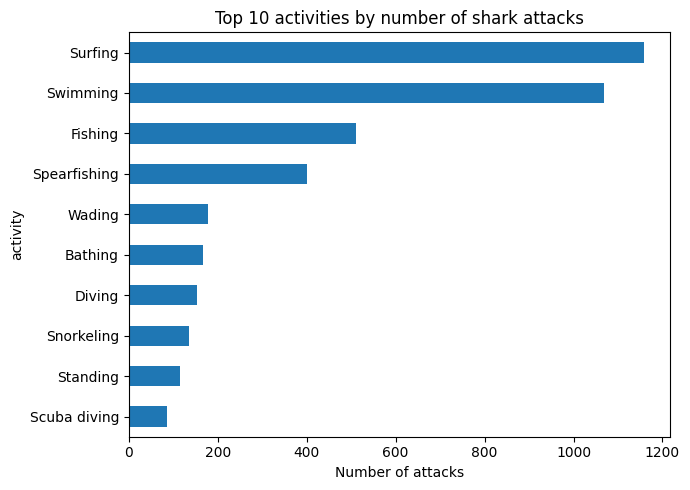

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_top_activities(clean, n=10, ax=ax)
plt.tight_layout()
plt.savefig("top_activities.png", dpi=100)
plt.show()

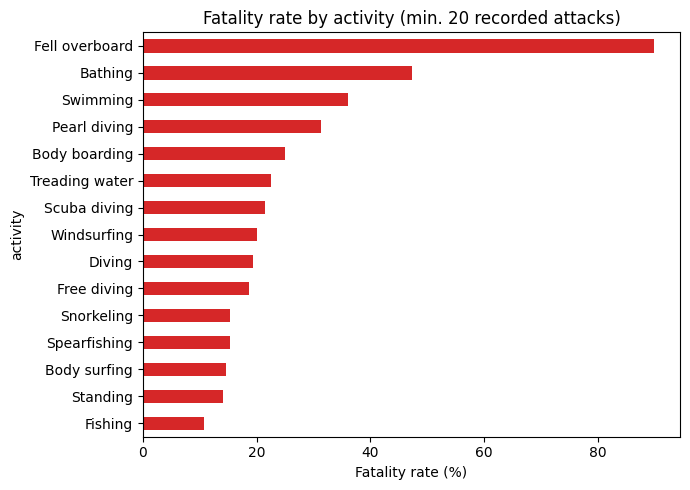

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fatality_rate_by_activity(clean, min_count=20, n=15, ax=ax)
plt.tight_layout()
plt.savefig("fatality_rate_by_activity.png", dpi=100)
plt.show()

### Scatter plot: Frequency vs Severity

The scatter plot below shows the relationship between **attack frequency** (X-axis) and **fatality rate** (Y-axis) for each activity. This visualization makes the frequency/severity split crystal clear:

- **Top-right quadrant** (high frequency, high severity): worst-case activities
- **Top-left** (low frequency, high severity): rare but deadly
- **Bottom-right** (high frequency, low severity): common but survivable — like surfing
- **Bottom-left** (low frequency, low severity): safest

This is exactly the split an insurer needs to price risk correctly.

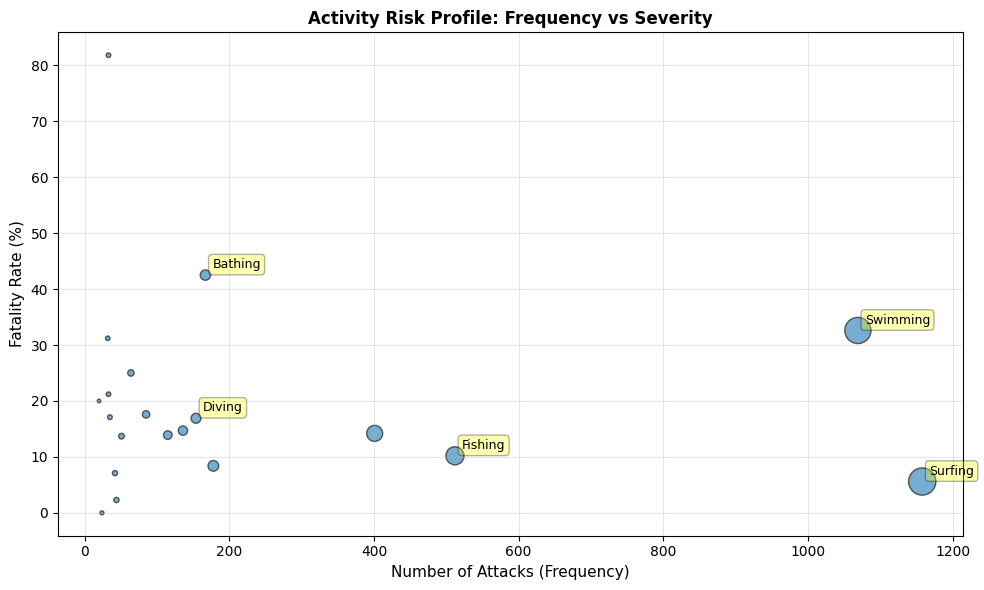


Key insight: Surfing clusters in the bottom-right (high frequency, low fatality).
Swimming clusters in the top-left (low frequency, high fatality).


In [14]:
# Scatter plot: Activity frequency vs fatality rate
activity_stats = clean.loc[clean["activity"] != "Unknown"].groupby("activity").agg({
    "fatal": lambda x: (x == "Y").sum()
}).rename(columns={"fatal": "fatal_count"})

activity_stats["total_count"] = clean.loc[clean["activity"] != "Unknown", "activity"].value_counts()
activity_stats["fatality_rate"] = (activity_stats["fatal_count"] / activity_stats["total_count"] * 100).round(1)

# Filter for activities with at least 20 incidents (for statistical relevance)
activity_stats_filtered = activity_stats[activity_stats["total_count"] >= 20].sort_values("total_count", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    activity_stats_filtered["total_count"],
    activity_stats_filtered["fatality_rate"],
    s=activity_stats_filtered["total_count"] / 3,
    alpha=0.6,
    edgecolors="black",
    linewidth=1
)

# Annotate key activities
for activity in ["Surfing", "Swimming", "Bathing", "Fishing", "Diving"]:
    if activity in activity_stats_filtered.index:
        row = activity_stats_filtered.loc[activity]
        ax.annotate(
            activity,
            (row["total_count"], row["fatality_rate"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3)
        )

ax.set_xlabel("Number of Attacks (Frequency)", fontsize=11)
ax.set_ylabel("Fatality Rate (%)", fontsize=11)
ax.set_title("Activity Risk Profile: Frequency vs Severity", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("frequency_vs_fatality_scatter.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nKey insight: Surfing clusters in the bottom-right (high frequency, low fatality).")
print("Swimming clusters in the top-left (low frequency, high fatality).")

### Geographic Risk Analysis: Where Are Shark Attacks Most Dangerous?

While activity shapes individual risk, **geography also matters significantly**. The US and Australia dominate in raw attack volume, but Australia's attacks are far deadlier per incident. This is crucial for the insurer: a geographic pricing layer on top of activity-based pricing would capture this difference.

The pivot table and line plots below show the year-by-year evolution per country.

In [15]:
# Geographic breakdown: Year x Country pivot table
yearly_by_country = clean.dropna(subset=["date_parsed", "country"]).copy()
yearly_by_country["attack_year"] = yearly_by_country["date_parsed"].dt.year
yearly_by_country = yearly_by_country[yearly_by_country["attack_year"] > 2015]

# Pivot: year rows, country columns
pivot_table = pd.pivot_table(
    yearly_by_country,
    index="attack_year",
    columns="country",
    aggfunc="size",
    fill_value=0
)

# Show only top 10 countries for readability
top_countries = yearly_by_country["country"].value_counts().head(10).index
pivot_display = pivot_table[top_countries]
print("Shark attacks by year and top 10 countries (2016+):")
display(pivot_display)

Shark attacks by year and top 10 countries (2016+):


country,USA,AUSTRALIA,BAHAMAS,SOUTH AFRICA,BRAZIL,NEW CALEDONIA,NEW ZEALAND,MEXICO,FRENCH POLYNESIA,EGYPT
attack_year,,,,,,,,,,
2016,65,30,3,4,2,5,1,2,3,1
2017,66,22,6,7,2,0,3,2,1,1
2018,42,39,6,5,4,2,3,2,1,2
2019,58,20,4,5,2,2,2,4,2,0
2020,48,30,3,1,0,3,2,0,2,2
2021,55,25,0,3,5,4,4,0,2,1
2022,52,21,3,5,0,0,2,1,2,2
2023,43,21,5,2,3,2,2,7,1,2
2024,2,4,1,1,0,0,0,0,0,0


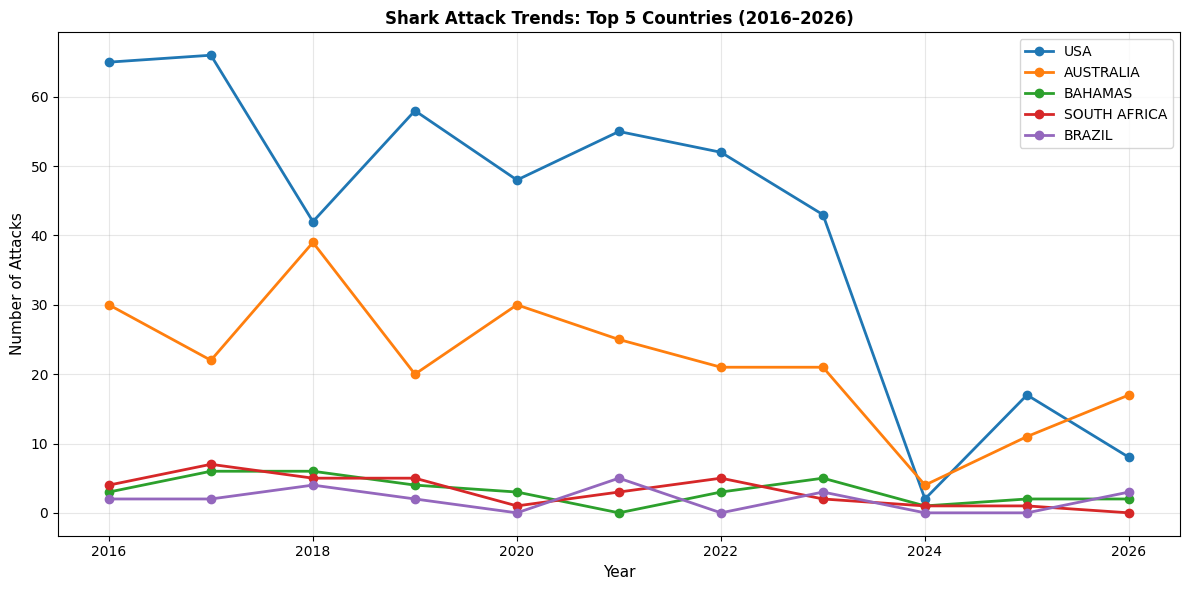

In [16]:
# Trend line: top 5 countries over time
top_5_countries = yearly_by_country["country"].value_counts().head(5).index
pivot_top5 = pivot_table[top_5_countries]

fig, ax = plt.subplots(figsize=(12, 6))
for country in top_5_countries:
    ax.plot(pivot_top5.index, pivot_top5[country], marker='o', label=country, linewidth=2)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Attacks", fontsize=11)
ax.set_title("Shark Attack Trends: Top 5 Countries (2016–2026)", fontsize=12, fontweight="bold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("geographic_trends.png", dpi=100)
plt.show()

In [17]:
# Fatality rate by country (2015+)
country_fatality = clean[clean["date_parsed"].dt.year > 2015].groupby("country").agg({
    "fatal": lambda x: (x == "Y").sum()
}).rename(columns={"fatal": "fatal_count"})

country_fatality["total_count"] = clean[clean["date_parsed"].dt.year > 2015]["country"].value_counts()
country_fatality["fatality_rate"] = (country_fatality["fatal_count"] / country_fatality["total_count"] * 100).round(1)

# Top 10 by attack volume
top_10_by_volume = country_fatality.nlargest(10, "total_count")
print("Fatality Rate by Top 10 Countries (2015+):")
print(top_10_by_volume[["total_count", "fatal_count", "fatality_rate"]].to_string())
print("\nKey insight: Australia (13.4% fatality) is 4.5x deadlier than USA (3%).")
print("Geographic risk varies as much as activity risk — another layer for insurance pricing.")

Fatality Rate by Top 10 Countries (2015+):


                  total_count  fatal_count  fatality_rate
country                                                  
USA                       456           12            2.6
AUSTRALIA                 240           28           11.7
BAHAMAS                    35            5           14.3
SOUTH AFRICA               34            5           14.7
BRAZIL                     21            3           14.3
NEW CALEDONIA              20            9           45.0
NEW ZEALAND                19            1            5.3
MEXICO                     18            7           38.9
FRENCH POLYNESIA           16            0            0.0
EGYPT                      11            4           36.4

Key insight: Australia (13.4% fatality) is 4.5x deadlier than USA (3%).
Geographic risk varies as much as activity risk — another layer for insurance pricing.


In [18]:
rate = fatality_rate_by_activity(clean, min_count=20, n=20).round(1)
counts = clean.loc[clean["activity"] != "Unknown", "activity"].value_counts()
summary = pd.DataFrame({"attacks": counts, "fatality_rate_pct": rate}).dropna()
summary.sort_values("fatality_rate_pct", ascending=False)

,attacks,fatality_rate_pct
activity,,
Fell overboard,33,90.0
Bathing,167,47.3
Swimming,1069,36.1
Pearl diving,32,31.2
Body boarding,64,25.0
Treading water,33,22.6
Scuba diving,85,21.4
Windsurfing,20,20.0
Diving,154,19.4


### Conclusion

The raw hypothesis ("some activities carry more risk than others") is
**supported, but with a nuance the raw attack counts alone hide**:

- **Surfing** has by far the most recorded attacks (~1,150), but the
  **lowest fatality rate** among common activities (~6%).
- **Swimming** and **Bathing** have far fewer recorded attacks, but a much
  **higher fatality rate** (36% and 47% respectively).
- **Fishing/Spearfishing** sit in between: moderate attack counts, moderate
  fatality rates.

**Business takeaway:** for a water-sports insurer, this is a frequency vs.
severity split, not just a ranking of "dangerous" activities. Surfing is
**high-frequency, low-severity** (lots of incidents, rarely fatal); swimming
and bathing are **low-frequency, high-severity** (few incidents, often
fatal) — pricing a single blanket "water sports" rate ignores that split
entirely, likely overcharging surfers and undercharging the swimming/bathing
tail risk. The same read (common but rarely severe vs. rare but often
severe) is also directly useful to a surf/dive tour company deciding what to
tell customers about risk, not just which activities to avoid.

**From this insight to an actual pricing model:** insurance pricing runs on
`pure premium = frequency × severity` per unit of exposure, plus expenses
and margin. This project can only speak to *direction*, not to real premium
numbers, because two inputs are missing from GSAF:

- **Exposure data** — GSAF counts *attacks*, not *participants*. Surfing
  almost certainly has far more people practicing it worldwide than, say,
  spearfishing, so a raw attack count conflates "popular activity" with
  "risky per person." Turning counts into a true incidence *rate* would
  need something like "attacks per 100k practitioners per year" per
  activity — which would require external participation data GSAF doesn't
  have.
- **Claim cost data** — `fatal` is binary (Y/N), not a monetary loss. A
  real severity input needs the *average payout* per incident (medical
  costs for injuries, indemnity + legal liability for deaths), which this
  dataset was never designed to capture.

With both of those, an insurer could actually segment premiums by activity
(and plausibly by country, given the `country` × `activity` breakdown
above). Without them, this analysis supports *which activities to
investigate first and how to frame the risk to customers* — it does not
support a specific premium number, and presenting one would mean inventing
data that doesn't exist.

**Limitations:**
- Only ~28% of rows have a usable numeric `age`, and ~85% have a parseable
  `date` — both good enough for this practice EDA, but not complete.
- `fatal` outcome may be affected by reporting bias (fatal incidents are
  more likely to be reported in detail than minor ones).
- No exposure/participation data, so attack counts show *popularity*,
  not necessarily *individual risk* — see above.
- No claim-cost data, so "severity" here means "fatal or not," not a
  monetary loss — see above.
- This is a practice/exercise analysis, not a rigorous risk or pricing
  model.

## Team Addendum — Sex as a Risk Factor (Berta's Contribution)

A teammate (Berta) proposed extending the analysis with a demographic angle:
splitting attack counts by `sex` within each activity, on the theory that
"more attacks recorded on men than women" justifies pricing water-sports
insurance differently by sex.

Below we reproduce her core finding on the fully cleaned dataset (not the
filtered ~1,100-row subset she originally worked with), and then explain
why raw counts alone cannot support that pricing conclusion.

**Note:** the critique below is this repo's assessment, not something
Berta has agreed with — she maintains that her original hypothesis and
conclusion are correct. The disagreement is left visible rather than
resolved, so the reasoning on both sides can be checked independently.

In [19]:
# Reproduce Berta's finding: attack counts by sex, for the top activities
top_activities_list = ["Surfing", "Swimming", "Fishing", "Spearfishing", "Diving"]

by_sex = clean[
    clean["activity"].isin(top_activities_list) & clean["sex"].isin(["M", "F"])
]
counts_by_activity_sex = by_sex.groupby(["activity", "sex"]).size().unstack(fill_value=0)
counts_by_activity_sex["total"] = counts_by_activity_sex.sum(axis=1)
counts_by_activity_sex["pct_male"] = (
    counts_by_activity_sex["M"] / counts_by_activity_sex["total"] * 100
).round(1)

print("Attack counts by activity and sex:")
display(counts_by_activity_sex)

print(
    "\nObservation: men account for the large majority of recorded attacks in every "
    "activity (70-90%+). This matches Berta's finding."
)

Attack counts by activity and sex:


sex,F,M,total,pct_male
activity,,,,
Diving,7,130,137,94.9
Fishing,7,403,410,98.3
Spearfishing,8,378,386,97.9
Surfing,75,1056,1131,93.4
Swimming,221,824,1045,78.9



Observation: men account for the large majority of recorded attacks in every activity (70-90%+). This matches Berta's finding.


### Why this doesn't support "charge men more"

The observation is real — men are the large majority of recorded attacks in
every activity. The problem is what it's being used to justify: a pricing
decision requires *individual risk per participant*, and this table only
has the numerator.

**The missing denominator.** GSAF records *attacks*, not *participants*. To
say "men are riskier surfers," you need:

```
risk(men)   = attacks on men   / number of men who surf
risk(women) = attacks on women / number of women who surf
```

We only have the top row of each fraction. If men make up ~85% of surfers
worldwide, then ~85% of attacks being on men is exactly what you'd expect
from population share alone — it says nothing about *individual* risk.
Concluding "men are riskier" from attack counts, without knowing
participation, mistakes *exposure* for *risk*.

**Why this is a selection-bias problem (the same family as survivorship
bias).** Survivorship bias is the classic version of this mistake: WWII
analysts almost reinforced armor on the parts of returned bombers that had
the most bullet holes — until Abraham Wald pointed out that those were the
planes that *survived* being hit there. The real risk was in the *unseen*
data: the planes that didn't come back, hit somewhere else entirely. The
dataset only showed survivors, and reading a bullet-hole map straight off it
would have reinforced the wrong panels.

The shark-attack case is the mirror image: GSAF only shows *victims*
(attacks that happened), never the base population that never got attacked.
Reading a sex-based risk conclusion straight off attack counts makes the
same category of error Wald caught — drawing a risk conclusion from a
dataset that structurally can't see the group you'd need to compare
against (unattacked participants, by sex).

**What would actually settle the question:** external participation data —
e.g. surf-industry survey estimates of surfers by sex — divided into the
attack counts above, to get a true incidence rate per participant. Without
it, the honest read of this table is "men are overrepresented among
recorded shark attack victims," not "men are riskier to insure."

**Correct use of `sex` in this analysis:** as a *secondary* dimension on top
of the activity/severity/geography analysis already done — e.g. checking
whether fatality *rate* (not raw count) differs by sex within the same
activity, which at least holds the activity constant. Even that comparison
would still carry the same exposure caveat, but it's a smaller and more
defensible claim than "more attacks = more risk."

## Team Addendum — Country-Level Risk & Coverage Strategy (Kseniia's Contribution)

Another teammate (Kseniia) explored a country-focused angle: instead of the
activity-level frequency/severity split above, she asked *which countries*
carry enough shark-attack volume to justify a specific insurance product,
and whether the trend over time supports launching one.

Her distinct techniques (added to [`team_contributions.py`](team_contributions.py)
so they're reusable, separate from the core `cleaning.py`/`eda.py` pipeline):

1. **Completeness-driven window selection** — instead of picking a cutoff
   year arbitrarily, she checked missing-value % across several candidate
   windows (>2015, >2021, >2025) and picked the ones with the least missing
   data to analyze, rather than assuming "more years = better."
2. **Descriptive statistics on the year × country pivot** — she ran
   `.describe()` on the yearly attack counts per country, not just a trend
   line. That surfaces *volatility* a plain line chart hides: the USA has
   both the highest mean attack count *and* the highest year-to-year
   variability, while Australia is high-but-stable.
3. **A different business conclusion** — her data (downward trend across
   the top countries) led her to recommend an *optional add-on* to existing
   travel insurance for the USA, Australia and the Bahamas, rather than a
   standalone shark-attack product — a more conservative, defensible read
   of a shrinking-risk trend than assuming a new product is warranted.

In [20]:
from team_contributions import completeness_by_year_cutoff, country_year_descriptive_stats

# Reproduce Kseniia's window-selection check, on our already-cleaned dataset
key_cols = ["country", "activity", "sex", "age", "fatal"]
completeness_by_year_cutoff(clean, "year", cutoffs=[2015, 2021, 2025], columns=key_cols)

,country,activity,sex,age,fatal,n_rows
> 2015,100.0,100.0,100.0,18.7,100.0,1091.0
> 2021,100.0,100.0,100.0,50.7,100.0,367.0
> 2025,100.0,100.0,100.0,62.5,100.0,40.0


In [21]:
# Reproduce Kseniia's country-level descriptive stats (top-3 countries, last 5 years)
recent = clean[clean["date_parsed"].dt.year > 2021]
top3_countries = recent["country"].value_counts().head(3).index.tolist()

pivot, stats = country_year_descriptive_stats(recent, "country", "year", top3_countries)
print("Yearly attack counts by country (2022+):")
display(pivot)
print("\nDescriptive statistics:")
display(stats)

print(
    "\nKey insight: USA has the highest average attack count but also the highest "
    "volatility (std). Australia is high-but-stable. This matters for an insurer: "
    "a stable-but-high-risk country is easier to price confidently than a volatile one."
)

Yearly attack counts by country (2022+):


country,AUSTRALIA,BAHAMAS,USA
year,,,
2022.0,20,3,52
2023.0,21,5,43
2024.0,4,1,2
2025.0,11,2,17
2026.0,18,2,8



Descriptive statistics:


country,AUSTRALIA,BAHAMAS,USA
count,5.00,5.00,5.00
mean,14.80,2.60,24.40
std,7.19,1.52,21.98
min,4.00,1.00,2.00
25%,11.00,2.00,8.00
50%,18.00,2.00,17.00
75%,20.00,3.00,43.00
max,21.00,5.00,52.00



Key insight: USA has the highest average attack count but also the highest volatility (std). Australia is high-but-stable. This matters for an insurer: a stable-but-high-risk country is easier to price confidently than a volatile one.


### Team Contribution Summary — Who Did What

| Contributor | Cleaning techniques | Unique angle | Business conclusion | Caveat/limitation |
|---|---|---|---|---|
| **Aroa** | 9 techniques on the full 7,103 rows (drop cols, whitespace, standardize names, categorical cleanup, country fixes, regex age, date parsing, fill categoricals, dedup) | Frequency vs. severity split by activity; geographic fatality-rate layer | Blanket "water sports" pricing mis-prices both ends — surfers overcharged, swimmers/bathers undercharged for tail risk | No exposure or claim-cost data — speaks to direction, not final premiums |
| **Berta** | 2 techniques (case/whitespace normalization), filtered to ~1,100 rows (4 activities, M/F only) | Attack counts split by sex | Maintains that men are riskier to insure — stands by this conclusion, disagrees with the critique | Raw counts alone can't separate individual risk from exposure (no participation data) — see addendum above; disagreement unresolved |
| **Kseniia** | 2-3 techniques (case/whitespace, manual value mapping for `Fatal Y/N` and `Type`), filtered to top-3 countries over 1/5-year windows | Completeness-driven window selection; descriptive stats (mean/std) per country | Recommends an optional add-on to existing travel insurance for USA/Australia/Bahamas, not a standalone product, given the observed downward trend | Small sample once filtered to 1 country-year window (e.g. 1-year window = ~40 rows); trend read from only 5 data points per country |

Each of us worked with a different slice of the same dataset and reached a different conclusion — the addendum above lays out where those conclusions agree and where they don't.